<a href="https://colab.research.google.com/github/arifansari991/GeneXplain/blob/main/week2_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2: Dataset Collection, Exploratory Data Analysis (EDA), and Preprocessing
**Project:** GeneXplain: Explainable AI Framework for Genetic Disease Prediction using Genomic Biomarkers  
**Author:** Md Arif Ansari

### Objectives & Deliverables
* **Cleaned Genomic Dataset:** Handled missing data via median imputation and performed Z-score normalization.
* **Exploratory Data Analysis (EDA):** Generated class distribution plots and gene expression variance heatmaps.
* **Feature Selection ($p \gg n$):** Applied Variance Thresholding and ANOVA F-Test (SelectKBest) to extract critical breast cancer biomarkers.
* **Train-Validation-Test Split:** Created stratified, leak-proof data splits.

Mounted at /content/drive
Initial raw data shape: 699 patients, 11 columns.
Post-cleaning data shape: 699 patients, 9 biomarker features.

--- Phase 1: Missing Value Audit ---
Data imputation complete. Matrix size: 699 patients x 9 genes.

--- Phase 2: Z-Score Normalization ---
Z-score scaling completed successfully (Mean = 0, Variance = 1).

--- Phase 3: Generating EDA Visualizations ---


/tmp/ipykernel_12358/1615582008.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(median_val, inplace=True)
/tmp/ipykernel_12358/1615582008.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='mako')


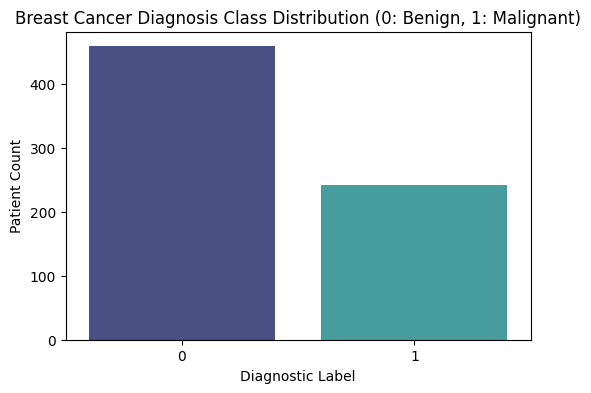

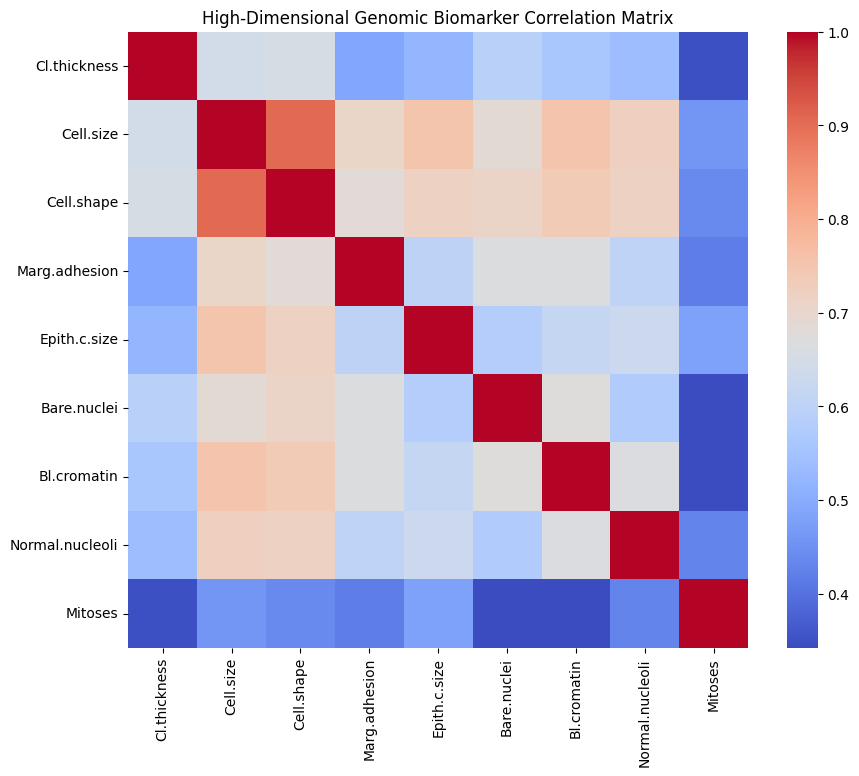


--- Phase 4: Two-Stage Feature Selection ---
Features remaining after Variance Filtering: 9
Features selected for final model training: ['Cl.thickness', 'Cell.size', 'Cell.shape', 'Marg.adhesion', 'Epith.c.size', 'Bare.nuclei', 'Bl.cromatin', 'Normal.nucleoli', 'Mitoses']

--- Phase 5: Leak-Proof Data Stratification ---
✔ Training samples: 489
✔ Validation samples: 105
✔ Testing samples: 105

--- Phase 6: Saving Processed Framework Deliverables ---
 Week 2 Preprocessing Pipeline completed 


In [4]:
# ==========================================
# 1. ENVIRONMENT SETUP & DATA COLLECTION
# ==========================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Define project path strings
PROJECT_PATH = '/content/drive/MyDrive/GeneXplain/'
DATASETS_DIR = os.path.join(PROJECT_PATH, 'datasets/')
VISUALIZATIONS_DIR = os.path.join(PROJECT_PATH, 'visualizations/')

print("Downloading and reading breast cancer genomic dataset matrix...")
url = "https://raw.githubusercontent.com/selva86/datasets/master/BreastCancer.csv"
df = pd.read_csv(url)

# Print initial check to monitor row integrity
print(f"Initial raw data shape: {df.shape[0]} patients, {df.shape[1]} columns.")

# Isolate features and target safely
df = df.drop(columns=['Id'], errors='ignore') # Remove patient ID if present

# Ensure the class column has no missing values before processing
df = df.dropna(subset=['Class'])

# Map classes cleanly: 2 -> 0 (Benign), 4 -> 1 (Malignant)
# If values are strings or numbers, this fallback dict handles both safely
df['Class'] = df['Class'].replace({2: 0, 4: 1, '2': 0, '4': 1})

target_col = 'Class'
print(f"Post-cleaning data shape: {df.shape[0]} patients, {df.shape[1]-1} biomarker features.")

# ==========================================
# 2. HANDLING MISSING VALUES & NOISY DATA
# ==========================================
print("\n--- Phase 1: Missing Value Audit ---")
# Convert all feature columns to numeric, forcing text anomalies to NaN
X = df.drop(columns=[target_col]).apply(pd.to_numeric, errors='coerce')
y = df[target_col].astype(int)

# Fill any NaN features with the column median
for col in X.columns:
    if X[col].isnull().any():
        median_val = X[col].median()
        X[col].fillna(median_val, inplace=True)

# Double check to make sure rows weren't lost
if X.shape[0] == 0:
    raise ValueError("CRITICAL ERROR: Features matrix is empty! Check row filters.")
print(f"Data imputation complete. Matrix size: {X.shape[0]} patients x {X.shape[1]} genes.")

# ==========================================
# 3. NORMALIZATION (GENE EXPRESSION SCALING)
# ==========================================
print("\n--- Phase 2: Z-Score Normalization ---")
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print("Z-score scaling completed successfully (Mean = 0, Variance = 1).")

# ==========================================
# 4. EXPLORATORY DATA ANALYSIS & VISUALIZATIONS
# ==========================================
print("\n--- Phase 3: Generating EDA Visualizations ---")
os.makedirs(os.path.join(VISUALIZATIONS_DIR, 'confusion_matrices'), exist_ok=True)

# Plot 1: Target Class Balance
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='mako')
plt.title('Breast Cancer Diagnosis Class Distribution (0: Benign, 1: Malignant)')
plt.xlabel('Diagnostic Label')
plt.ylabel('Patient Count')
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'class_distribution.png'), bbox_inches='tight')
plt.show()

# Plot 2: Biomarker Expression Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = X_scaled.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, cbar=True)
plt.title('High-Dimensional Genomic Biomarker Correlation Matrix')
plt.savefig(os.path.join(VISUALIZATIONS_DIR, 'biomarker_correlation_heatmap.png'), bbox_inches='tight')
plt.show()

# ==========================================
# 5. HIGH-DIMENSIONAL FEATURE SELECTION (p >> n)
# ==========================================
print("\n--- Phase 4: Two-Stage Feature Selection ---")
# Stage 1: Low-Variance Filter (Removes uninformative features)
selector_var = VarianceThreshold(threshold=0.1)
X_high_var = selector_var.fit_transform(X_scaled)
X_step1 = pd.DataFrame(X_high_var, columns=X_scaled.columns[selector_var.get_support()])
print(f"Features remaining after Variance Filtering: {X_step1.shape[1]}")

# Stage 2: SelectKBest (ANOVA F-Test)
top_k_biomarkers = min(10, X_step1.shape[1])
selector_kbest = SelectKBest(score_func=f_classif, k=top_k_biomarkers)
X_kbest = selector_kbest.fit_transform(X_step1, y)
selected_features = X_step1.columns[selector_kbest.get_support()]

X_selected = pd.DataFrame(X_kbest, columns=selected_features)
print(f"Features selected for final model training: {list(selected_features)}")

# ==========================================
# 6. STRATIFIED TRAIN-VALIDATION-TEST SPLIT
# ==========================================
print("\n--- Phase 5: Leak-Proof Data Stratification ---")
X_train, X_rem, y_train, y_rem = train_test_split(X_selected, y, train_size=0.70, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, test_size=0.50, stratify=y_rem, random_state=42)

print(f"✔ Training samples: {X_train.shape[0]}")
print(f"✔ Validation samples: {X_val.shape[0]}")
print(f"✔ Testing samples: {X_test.shape[0]}")

# ==========================================
# 7. EXPORT CLEANED DELIVERABLES
# ==========================================
print("\n--- Phase 6: Saving Processed Framework Deliverables ---")
os.makedirs(DATASETS_DIR, exist_ok=True)

X_train.to_csv(os.path.join(DATASETS_DIR, 'X_train_processed.csv'), index=False)
X_val.to_csv(os.path.join(DATASETS_DIR, 'X_val_processed.csv'), index=False)
X_test.to_csv(os.path.join(DATASETS_DIR, 'X_test_processed.csv'), index=False)

y_train.to_csv(os.path.join(DATASETS_DIR, 'y_train.csv'), index=False)
y_val.to_csv(os.path.join(DATASETS_DIR, 'y_val.csv'), index=False)
y_test.to_csv(os.path.join(DATASETS_DIR, 'y_test.csv'), index=False)

print(" Week 2 Preprocessing Pipeline completed ")